# Обучение AutoGluon Quantile Regression

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:

from autogluon.tabular import TabularPredictor
import os

/opt/miniconda3/envs/ag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка исходных данных (с новыми признаками)

In [4]:
train = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/train_selected.csv')
train.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed,pIC50,pCC50,log10_SI
0,2.471240,-2.203512,2.178787,0.155539,32.166506,10.291948,2.063714,0.241070,2.590056,2.162989,...,0,0,0,1,0,0,0.681165,0.989639,1.018827,-0.029188
1,2.314947,-2.449813,2.456783,-0.003171,35.495692,9.631497,2.157249,0.155411,3.202665,5.979250,...,0,0,0,0,0,0,0.769122,4.353274,2.075665,2.277609
2,2.579710,-2.562182,2.584438,-0.007335,16.507764,9.486685,1.480238,0.332383,3.271705,3.649563,...,0,0,0,0,0,0,0.612606,2.352816,1.300287,1.052529
3,3.101827,-2.040425,2.409619,-0.384432,32.227747,10.102030,2.026965,0.162038,4.970214,5.111900,...,0,0,0,0,0,0,0.345823,2.165714,0.165714,2.000000
4,1.787472,-2.547053,2.539193,0.000365,14.788664,9.531931,1.940004,0.308846,3.002350,1.657054,...,0,0,0,0,0,0,0.562066,2.698264,1.154893,1.543371


In [5]:
test = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/test_selected.csv')
test.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_ketone_Topliss,fr_methoxy,fr_nitro,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed
0,3.494848,-2.425359,2.544663,-0.147725,32.166547,9.704289,1.531269,0.173188,3.264259,3.565174,...,0,0,0,0,0,0,1,0,0,0.770057
1,2.752143,-2.390353,2.369524,-0.277225,16.707906,9.991346,1.885708,0.269334,4.373269,2.230052,...,0,0,0,3,0,0,0,0,0,0.278628
2,2.001545,-2.580818,2.603245,-0.063729,14.717158,9.477838,1.911265,0.320711,3.081114,2.190560,...,0,0,0,0,0,0,0,0,0,0.657472
3,3.093791,-2.378300,2.497185,-0.343838,19.431747,9.748466,2.061305,0.161809,4.035225,4.196103,...,1,0,0,0,0,0,0,0,0,0.564307
4,2.896060,-2.201773,2.471778,-0.097822,16.731298,9.952325,1.940561,0.093867,3.310435,2.390479,...,1,0,0,0,0,0,0,0,0,0.696213


In [6]:
print(train.shape)
print(test.shape)

(751, 113)
(250, 110)


In [7]:
# ==========================================
# 1. НАСТРОЙКИ ДЛЯ ОДНОГО ТАРГЕТА
# ==========================================
target = 'log10_SI'
other_targets = ['pIC50', 'pCC50']

save_path = '/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/log_models_SI'
quantile_levels = [0.1, 0.5, 0.9, 0.95]

print(f"\n{'='*50}")
print(f"Обучение AutoGluon для таргета: {target}")
print(f"{'='*50}")

# 1) Удаляем другие таргеты
train_data_target = train.drop(columns=other_targets, errors='ignore').copy()

print("train_data_target shape:", train_data_target.shape)
print("Количество признаков:", train_data_target.shape[1] - 1)
print("Quantile levels:", quantile_levels)

# ==========================================
# 2. СОЗДАЕМ ПРЕДИКТОР ДЛЯ QUANTILE REGRESSION
# ==========================================
predictor = TabularPredictor(
    label=target,
    path=os.path.join(save_path, f"model_{target}_quantile"),
    problem_type='quantile',
    quantile_levels=quantile_levels
)

# ==========================================
# 3. ЗАПУСКАЕМ ОБУЧЕНИЕ
# ==========================================
predictor.fit(
    train_data=train_data_target,
    presets='best_quality',
    time_limit=1800,
    calibrate=True,
    feature_prune_kwargs={'force_prune': True},
    num_bag_folds=5,
    num_bag_sets=1,
    num_stack_levels=1,
    keep_only_best=True
)

print(f"Обучение quantile-модели для таргета {target} завершено.")

Verbosity: 2 (Standard Logging)



Обучение AutoGluon для таргета: log10_SI
train_data_target shape: (751, 111)
Количество признаков: 110
Quantile levels: [0.1, 0.5, 0.9, 0.95]


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:34 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T8103
CPU Count:          8
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.67 GB / 8.00 GB (33.4%)
Disk Space Avail:   27.43 GB / 228.27 GB (12.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stac

Обучение quantile-модели для таргета log10_SI завершено.


In [8]:
# 1. Оценка качества на кросс-валидации (OOF)
print(f"\n--- Результаты кросс-валидации для {target} ---")
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard[['model', 'score_val', 'fit_time']])

print(f"\n Лучшая модель: {predictor.model_best}")


--- Результаты кросс-валидации для log10_SI ---
                         model  score_val   fit_time
0          WeightedEnsemble_L3  -0.127299  48.806970
1       ExtraTrees_r172_BAG_L2  -0.127718  34.961476
2         CatBoost_r137_BAG_L2  -0.130140  44.109725
3            LightGBMXT_BAG_L2  -0.130694  35.665998
4     RandomForest_r127_BAG_L1  -0.132237   4.307370
5       ExtraTrees_r172_BAG_L1  -0.132447   2.236789
6            LightGBMXT_BAG_L1  -0.133497   2.447993
7    NeuralNetTorch_r87_BAG_L1  -0.133542   7.835544
8          CatBoost_r50_BAG_L1  -0.135431   9.869797
9  NeuralNetFastAI_r143_BAG_L1  -0.137977   6.276925

 Лучшая модель: WeightedEnsemble_L3


In [9]:
# Предсказание log10_SI на тесте
print("\nГенерация предсказаний log10_SI для тестового набора...")
pred_test_quantiles_SI = predictor.predict(test) 
print(pred_test_quantiles_SI.head())
print(pred_test_quantiles_SI.columns)


Генерация предсказаний log10_SI для тестового набора...
       0.10      0.50      0.90      0.95
0  0.006106  0.477824  1.409674  1.523916
1 -0.056841  0.522989  1.102784  1.394411
2  0.346621  0.740733  1.328946  1.566636
3 -0.001345  0.414572  1.314621  1.489218
4 -0.004056  0.343971  0.863063  1.099476
Index([0.1, 0.5, 0.9, 0.95], dtype='float64')


In [10]:
# 1. Узнаем точное имя лучшей модели
best_model_name = predictor.model_best
print(f" Лучшая модель: {best_model_name}\n")

# 2. Достаем всё досье на эту модель
model_details = predictor.model_info(best_model_name)

# 3. Смотрим, какие базовые модели в нее вошли (и с какими весами)
print(" Веса базовых моделей в ансамбле:")
# Если это ансамбль, у него есть ключ 'children_info' или 'stacker_info'
if 'children_info' in model_details:
    # Выводим веса (какая модель внесла наибольший вклад)
    weights = model_details['children_info']['S1F1']['model_weights']
    for model, weight in weights.items():
        if weight > 0: # Показываем только те, что реально используются
            print(f"  - {model}: {weight:.4f}")

# 4. Выводим гиперпараметры самого ансамбля
print("\n Гиперпараметры лучшей модели:")
print(model_details['hyperparameters'])

 Лучшая модель: WeightedEnsemble_L3

 Веса базовых моделей в ансамбле:
  - RandomForest_r127_BAG_L1: 0.2222
  - LightGBMXT_BAG_L2: 0.0556
  - CatBoost_r137_BAG_L2: 0.0556
  - ExtraTrees_r172_BAG_L2: 0.6667

 Гиперпараметры лучшей модели:
{'use_orig_features': False, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}


In [11]:
# Заново достаем информацию о лучшем ансамбле
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" Гиперпараметры базовых моделей, вошедших в ансамбль:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    # Проходимся по каждой модели, которая получила вес больше 0
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            # Извлекаем досье на конкретную базовую модель
            base_info = predictor.model_info(base_model)
            print("Параметры:", base_info['hyperparameters'])
            print("-" * 50)

 Гиперпараметры базовых моделей, вошедших в ансамбль:

 Модель: RandomForest_r127_BAG_L1 (Вес: 0.2222)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: LightGBMXT_BAG_L2 (Вес: 0.0556)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: CatBoost_r137_BAG_L2 (Вес: 0.0556)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_

In [12]:
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" ИСТИННЫЕ гиперпараметры алгоритмов:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            base_info = predictor.model_info(base_model)
            
            # Вскрываем обертку _BAG и берем параметры модели из первого фолда (S1F1)
            if 'children_info' in base_info and 'S1F1' in base_info['children_info']:
                real_params = base_info['children_info']['S1F1']['hyperparameters']
                print("Настоящие параметры:", real_params)
            else:
                print("Настоящие параметры:", base_info.get('hyperparameters', 'Не найдены'))
            print("-" * 50)

 ИСТИННЫЕ гиперпараметры алгоритмов:

 Модель: RandomForest_r127_BAG_L1 (Вес: 0.2222)
Настоящие параметры: {'n_estimators': 300, 'max_leaf_nodes': 38572, 'n_jobs': -1, 'bootstrap': True, 'max_features': 1.0, 'min_samples_leaf': 5, 'random_state': 0}
--------------------------------------------------
 Модель: LightGBMXT_BAG_L2 (Вес: 0.0556)
Настоящие параметры: {'learning_rate': 0.05, 'extra_trees': True, 'seed': 0}
--------------------------------------------------
 Модель: CatBoost_r137_BAG_L2 (Вес: 0.0556)
Настоящие параметры: {'iterations': 10000, 'learning_rate': 0.04939557741379516, 'allow_writing_files': False, 'eval_metric': 'MultiQuantile:alpha=0.1,0.5,0.9,0.95', 'depth': 4, 'grow_policy': 'SymmetricTree', 'l2_leaf_reg': 4.559174625782161, 'max_ctr_complexity': 3, 'one_hot_max_size': 3, 'random_seed': 0}
--------------------------------------------------
 Модель: ExtraTrees_r172_BAG_L2 (Вес: 0.6667)
Настоящие параметры: {'n_estimators': 300, 'max_leaf_nodes': 12845, 'n_jobs': -

In [13]:
# 1. Берем только q50 и q90 для log10_SI
pred_q10 = pred_test_quantiles_SI[0.10]
pred_q50 = pred_test_quantiles_SI[0.50]
pred_q90 = pred_test_quantiles_SI[0.90]

# 2. Обратное преобразование из log10_SI -> SI, mM
pred_SI_q10 = np.power(10, pred_q10)
pred_SI_q50 = np.power(10, pred_q50)
pred_SI_q90 = np.power(10, pred_q90)

# 3. Собираем в DataFrame
preds_df_SI = pd.DataFrame({
    "SI_q10": pred_SI_q10,
    "SI_q50": pred_SI_q50,
    "SI_q90": pred_SI_q90
})

# 4. Сохранение
save_filename = "/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_SI_q50_q90.csv"
preds_df_SI.to_csv(save_filename, index=False)

print(f"Файл {save_filename} успешно сохранен!")
print(preds_df_SI.head())

Файл /Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_SI_q50_q90.csv успешно сохранен!
     SI_q10    SI_q50     SI_q90
0  1.014159  3.004862  25.684666
1  0.877321  3.334183  12.670206
2  2.221371  5.504696  21.327780
3  0.996908  2.597597  20.635807
4  0.990705  2.207856   7.295627


In [14]:
preds_df_SI.describe()

,SI_q10,SI_q50,SI_q90
count,250.000000,250.000000,250.000000
mean,1.738752,12.981387,167.539215
std,2.746323,33.445400,663.713074
min,0.072237,1.153724,3.840760
25%,0.990332,2.588324,17.112993
50%,1.005349,3.671730,26.112457
75%,1.155984,7.672009,48.852110
max,20.539394,283.083344,5463.145020


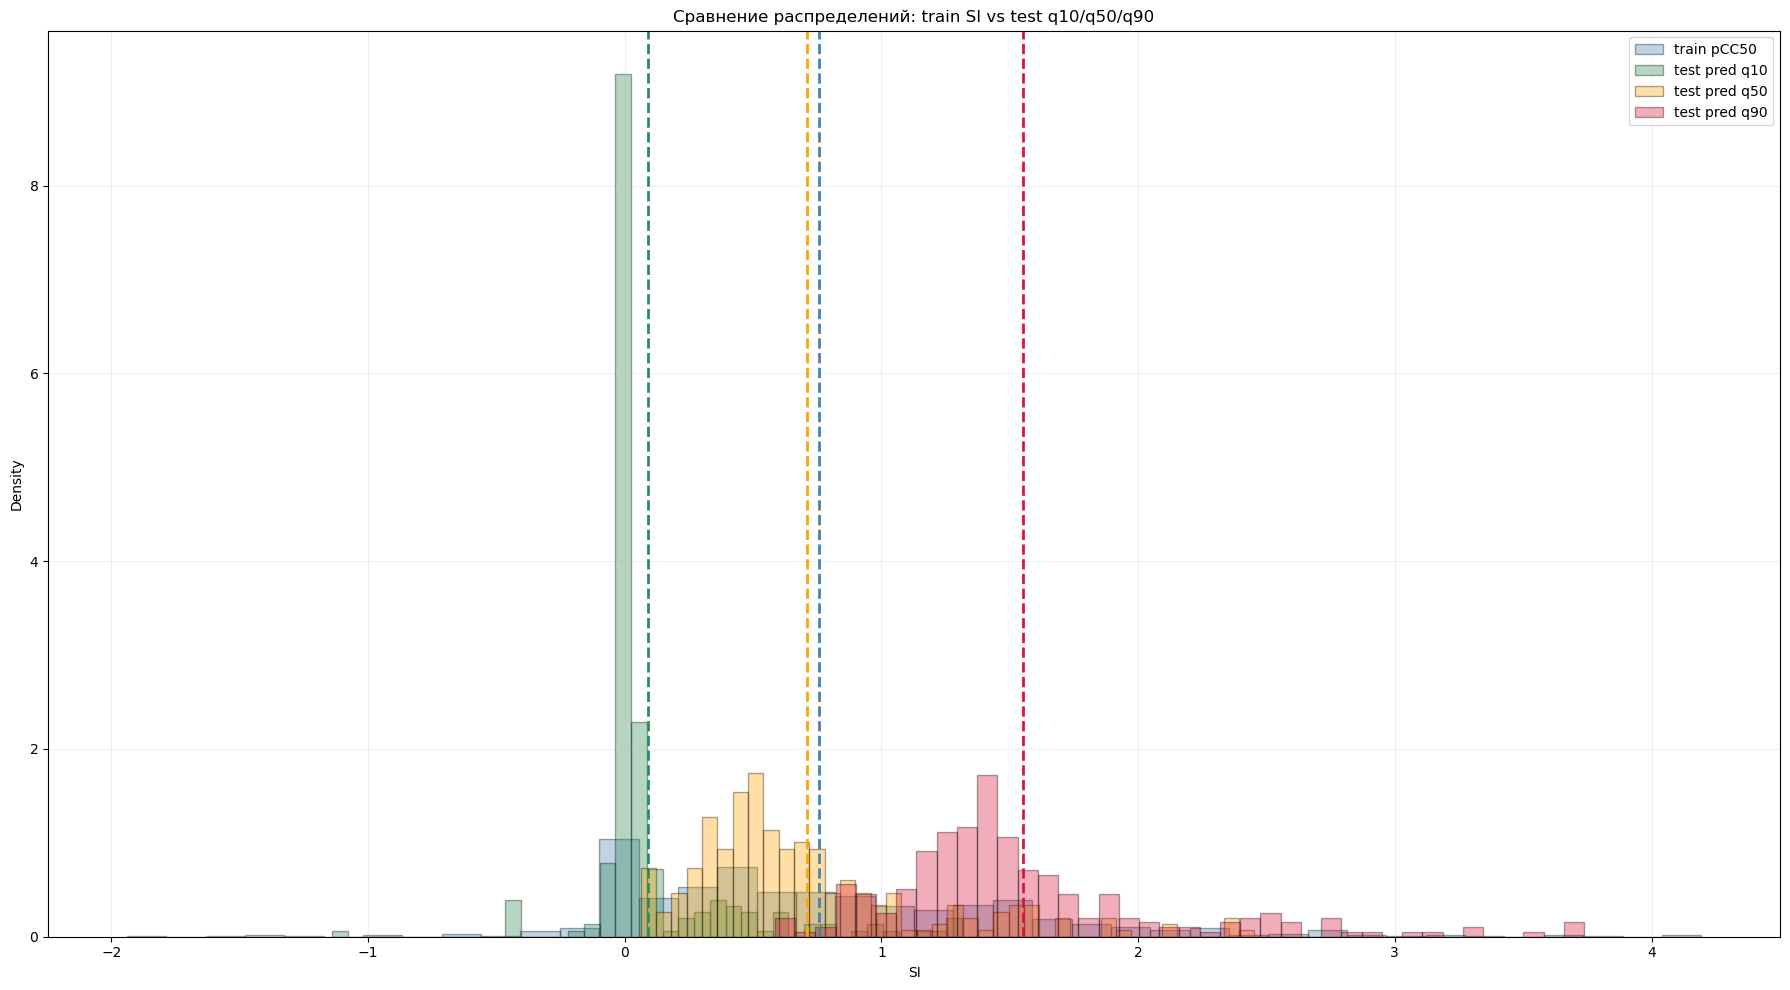

In [15]:
# логарифмический таргет train
train_pcc50 = train["log10_SI"].dropna()

# логарифмические предсказания квантилей на test
pred_q10 = pred_test_quantiles_SI[0.10]
pred_q50 = pred_test_quantiles_SI[0.50]
pred_q90 = pred_test_quantiles_SI[0.90]

plt.figure(figsize=(18, 10))

# train
plt.hist(
    train_pcc50,
    bins=40,
    alpha=0.35,
    label="train pCC50",
    color="steelblue",
    edgecolor="black",
    density=True
)

# q10
plt.hist(
    pred_q10,
    bins=40,
    alpha=0.35,
    label="test pred q10",
    color="seagreen",
    edgecolor="black",
    density=True
)

# q50
plt.hist(
    pred_q50,
    bins=40,
    alpha=0.35,
    label="test pred q50",
    color="orange",
    edgecolor="black",
    density=True
)

# q90
plt.hist(
    pred_q90,
    bins=40,
    alpha=0.35,
    label="test pred q90",
    color="crimson",
    edgecolor="black",
    density=True
)

# вертикальные линии средних
plt.axvline(train_pcc50.mean(), color="steelblue", linestyle="--", linewidth=2)
plt.axvline(pred_q10.mean(), color="seagreen", linestyle="--", linewidth=2)
plt.axvline(pred_q50.mean(), color="orange", linestyle="--", linewidth=2)
plt.axvline(pred_q90.mean(), color="crimson", linestyle="--", linewidth=2)

plt.title("Сравнение распределений: train SI vs test q10/q50/q90")
plt.xlabel("SI")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

График показывает, что для `SI` квантиль `q50` лучше всего отражает центральную часть обучающего распределения, тогда как `q10` заметно смещён влево и даёт слишком заниженные значения, а `q90` существенно смещён вправо и описывает завышенный верхний сценарий.

Таким образом, `q50` можно рассматривать как основной и наиболее сбалансированный прогноз для `SI`, а `q10` и `q90` — как нижнюю и верхнюю границы возможных значений соответственно.